In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import t, norm
from scipy.interpolate import lagrange

# Local Regression

Local regression is a statistical technique used to estimate the relationship between a response variable and a predictor by focusing on observations that are close to a given value. In this task, a local regression model is developed to predict **MORT** using **POOR** as the predictor. The model is then applied to the air pollution dataset to estimate mortality rates for areas where **10%, 18%, and 25%** of families have an income below **$3,000**, along with the corresponding standard errors of the predictions.


In [2]:
### x should be of the form (X_1,X_2,...), where X_i is a row vector of n observations and i is the number of features
data = pd.read_csv("pollution_cleaneddata.csv")
y,x  = data['MORT'], data['POOR']

In [3]:
def plot_local ( ax1, ax2, sorted_x, sorted_y, f_hat, int_points, local_confidence_interval, initiate = True):

    if initiate:  
        ax1.plot(int_points, f_hat(int_points), color='black', linewidth = 0.9, label='local best-fit line')
        ax1.scatter(sorted_x, sorted_y, facecolors='none', edgecolors='red', s=80, label='closest neighbors')
        ax1.fill_between(int_points, local_confidence_interval[0], local_confidence_interval[1], alpha=0.1, color='red', label="95% Confidence Interval")
            
    ax1.plot(int_points, f_hat(int_points), color='black', linewidth = 0.9)
    ax1.scatter(sorted_x, sorted_y, facecolors='none', edgecolors='red', s=80)
    ax1.fill_between(int_points,  local_confidence_interval[0], local_confidence_interval[1], alpha=0.1, color='red')

def plot_global ( fig, ax1, ax2, x0_list, predictions, k, interpolation_points, confidence_interval, save_title = f"LocalRegression.png", save=False):

    order        = len(interpolation_points[0]) - 1
    coefficients = np.polyfit(interpolation_points[0], interpolation_points[1], order)
    ploynomial   = np.poly1d(coefficients)
    xrange       = np.unique(np.concatenate((x, x0_list)))
    xpoints      = np.linspace(min(xrange), max(xrange), 500)
    #xpoints      = np.linspace(0.95*min(xrange), 1.05*max(xrange), 500)

    lCI_coefficients = np.polyfit(interpolation_points[0], confidence_interval[0], order)
    lCI_ploynomial   = np.poly1d(lCI_coefficients)
    uCI_coefficients = np.polyfit(interpolation_points[0], confidence_interval[1], order)
    uCI_ploynomial   = np.poly1d(uCI_coefficients)

    polynomial_residual = y - ploynomial(x)
    residual_mean       = np.mean(polynomial_residual)    
    
    ax1.scatter(x, y, color='blue', label='data points')
    ax1.scatter(x0_list, predictions, color='black', marker='x', label ='prediction')   
    ax1.plot(xpoints, ploynomial(xpoints), color='grey', linestyle='--', linewidth=1, label = "polynomial fit")  
    ax1.plot(xpoints, lCI_ploynomial(xpoints), color='red', linestyle='--', linewidth=1)  
    ax1.plot(xpoints, uCI_ploynomial(xpoints), color='red', linestyle='--', linewidth=1, label = "CI polynomial fit")  
    ax1.fill_between(xpoints, lCI_ploynomial(xpoints), uCI_ploynomial(xpoints), alpha=0.2, color='magenta')

    ax1.set_ylabel("MORTALITY RATE")
    ax1.legend(loc="upper left")
    ax1.set_ylim([0.95*min(y), 1.05*max(y)])
    #ax1.set_xlim([0.95*min(xrange), 1.05*max(xrange)])
    
    ax2.scatter(x, polynomial_residual, color='red')
    ax2.axhline(residual_mean, linestyle="--", color='red', label=f'mean residual = {residual_mean:.3f}')
    ax2.set_ylabel("SIGNED RESIDUAL")
    ax2.legend(loc="upper right")
    #ax2.set_xlim([0.95*min(xrange), 1.05*max(xrange)])
    
    fig.suptitle("Simple Linear Regression for Poorness vs Mortality Rate data", fontsize=20, y=0.98)
    fig.supxlabel("POORNESS RATE")

    ax1.grid(True, alpha=0.5)
    ax2.grid(True, alpha=0.5)
    plt.tight_layout()

    if save: plt.savefig(save_title, dpi=300, bbox_inches="tight")
    plt.show()


### Local Regression as an Optimization Problem

The simple local regression problem can be formulated as an optimization problem. Let \(x_0\) denote the predictor value for which we want to estimate the corresponding response. Given a dataset containing response values \(y_i\) and predictor values \(x_i\), where \(i = 1,\ldots,k\) and \(k\) represents the number of observations neighboring \(x_0\), the residual function can be defined as

$$
Q(\beta_0,\beta_1)
=
\sum_{i=1}^{k}
K_i\left(y_i-\beta_0-\beta_1x_i\right)^2.
$$

Here, \(K_i\) represents the weight assigned to each neighboring observation, with the specific weights determined later in the analysis. The objective is to minimize this function by finding the optimal values of \(\beta_0\) and \(\beta_1\). This minimization can be carried out using an appropriate optimization package in Python.


In [4]:
def linear_regression(y, x, k, x0_list, weight_function , plot=False, fig = None, ax1= None, ax2=None, save_title = None, save = False):
    k  = min(k, len(y)) #Ensures we only use the maximum amount of available neighbors
    l_alpha = t.ppf(0.975, k - 2) # Lambda_alpha value for 95% confidence interval
    
    predictions    = np.zeros_like(x0_list, dtype=float)
    standard_error = np.zeros_like(x0_list, dtype=float)
    
    confidence_interval  = np.zeros((2, len(x0_list)*3 ), dtype=float) #([upper], [lower])
    interpolation_points = np.zeros((2, len(x0_list)*3 ), dtype=float) #([x] , [y])

    for i,x0 in enumerate(x0_list):
        ###(I) Identify the corresponding {k} response values
        distances  = abs (x-x0)
        neighbors  = np.argsort(distances)[:k]
        local_y    = np.array(y[neighbors])
        local_x    = np.array(x[neighbors])   
        sorted_idx = np.argsort(local_x)
        sorted_x   = local_x[sorted_idx]
        sorted_y   = local_y[sorted_idx]
        x_bar      = np.mean(sorted_x)
        nbetas     = 2
        weights    = weight_function(distances[neighbors])
        
        ###(II) )Minimizing the resdiual by optimizing the parameters (b0,b1)
        betas = minimize(lambda betas: (sorted_y - betas @ np.column_stack((np.ones((sorted_x.shape[0])), sorted_x)).T)**2@weights,
                         np.zeros((nbetas))).x[:nbetas]   
        f_hat = lambda x: betas[0] + betas[1] * x
        
        ###(III)Calculate the variances and confidence intervals for each prediction. 
        residual     = sorted_y - f_hat(sorted_x)
        res_variance = np.sum(residual**2)/(k-2)
        est_variance = res_variance * (1/k + (x0-x_bar)**2 / np.sum((sorted_x-x_bar)**2))        

        predictions[i]    = f_hat(x0)
        standard_error[i] = np.sqrt(est_variance)

        int_points = np.array([x0-0.7,x0,x0+0.7])
        interpolation_points[:,i*3:(i+1)*3] = np.array([int_points, f_hat(int_points)])
        confidence_interval[:,i*3:(i+1)*3]  = np.array([f_hat(int_points) -l_alpha * np.sqrt(est_variance),
                                                        f_hat(int_points) +l_alpha * np.sqrt(est_variance)])
        
        if plot: plot_local( ax1, ax2 , sorted_x, sorted_y, f_hat, int_points, confidence_interval[:,i*3:(i+1)*3], initiate = (i==0))
            
    if plot: plot_global ( fig, ax1, ax2 ,x0_list, predictions, k, interpolation_points, confidence_interval, save_title = save_title, save=save)
    return predictions, standard_error

### Local Regression Estimates and Confidence Intervals

Local regression estimates were obtained for **POOR = 10%, 18%, and 25%**. These three estimates were then interpolated across the range of the predictor variable to produce a continuous fitted curve. In addition, the corresponding **95% confidence intervals** were interpolated between the three prediction points, resulting in a confidence band that varies across the predictor range.

### Weighting Strategy

The simple approach we considered for determining the weights $K_i$:

* **Method 1: Relative distance between predictors**

  $$
  K_i = 1 - \frac{ |x_0-x_i|}{\max_j |x_0-x_j|} \quad \forall j=1,...,k.
  $$

* **Method 2: Relative distance between predictors (Cubic - Faster Convergence)**
  
  $$
  K_i = (1 - (\frac{ |x_0-x_i|}{\max_j |x_0-x_j|})^3)^3 \quad \forall j=1,...,k.
  $$

* **Method 3: Normal (Gaussian) density function**

  $$
  K_i = \frac{1}{\sqrt{2\pi}}\exp(-(x_0-x_i)^2/2)
  $$

These three weighting strategies provide different ways of determining how much influence each neighboring observation has on the local regression estimate.


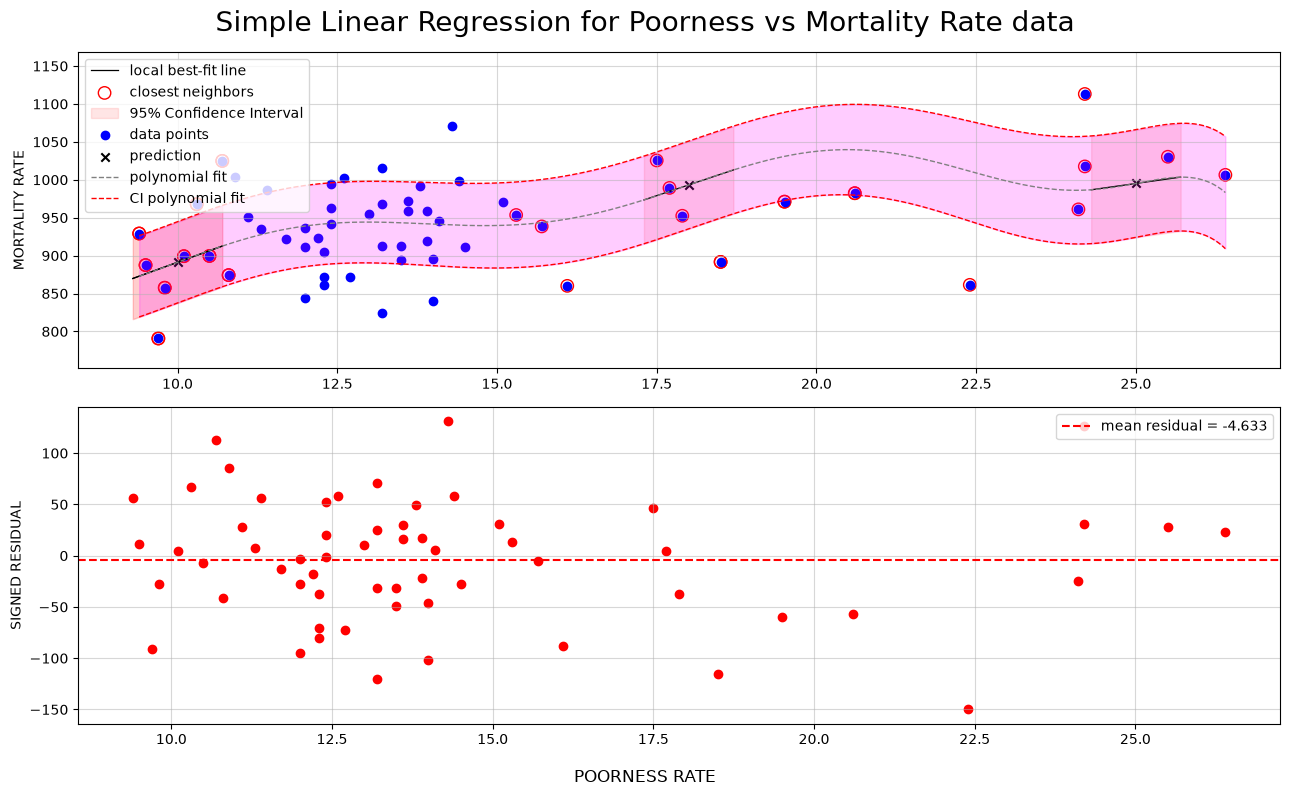

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

k  =  9
x0_list =  [10,18,25]

#weight_function = lambda distances: 1 - distances/max(distances) 
weight_function = lambda distances: (1 - (distances/max(distances))**3)**3
#weight_function = lambda distances: norm.pdf(distances)

pred, se = linear_regression(y, x, k, x0_list, weight_function , plot=True, fig = fig, ax1= ax1, ax2=ax2)

The local regression model was used to estimate the total age-adjusted mortality rate for areas with different percentages of families having an income below $3,000. The resulting predictions and their corresponding standard errors are presented below.

| **POOR (%)** | **Method 1: Predicted Mortality Rate** | **Method 1: Standard Error** | **Method 2: Predicted Mortality Rate** | **Method 2: Standard Error** | **Method 3: Predicted Mortality Rate** | **Method 3: Standard Error** |
| :----------: | :------------------------------------: | :--------------------------: | :------------------------------------: | :--------------------------: | :------------------------------------: | :--------------------------: |
|      10      |                 900.12                 |             22.02            |                 891.19                 |             22.67            |                 898.98                 |             21.97            |
|      18      |                 978.53                 |             20.22            |                 993.19                 |             24.44            |                 985.99                 |             22.10            |
|      25      |                 998.68                 |             29.74            |                 995.16                 |             30.03            |                 933.56                 |             42.18            |
